<a href="https://colab.research.google.com/github/anhtin18/SGU26_Ml/blob/main/Baocao_tieuduong.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Đánh giá bệnh tiểu đường

## 1. Định nghĩa vấn đề (Define Problem)
 **Mô tả**
Tổng quan
- Bộ dữ liệu gồm **768 mẫu** được thu thập từ phụ nữ thuộc quần thể *Pima Indians* (Mỹ).
- Mục tiêu: **Dự đoán khả năng mắc bệnh tiểu đường** trong tương lai.
- Thuộc loại bài toán: **Binary Classification (Phân loại nhị phân)**.
---
 Nhãn (Target)
- `Outcome = 0`: Không mắc tiểu đường  
- `Outcome = 1`: Mắc tiểu đường  

Đặc điểm dữ liệu
- Dữ liệu dạng: **Tabular (dạng bảng)**
- Tất cả biến đầu vào đều là **numeric**
- Số lượng đặc trưng: **8**
- Có thể tồn tại **giá trị thiếu (0 bất hợp lý)** ở một số biến như:
  - Glucose, BloodPressure, SkinThickness, Insulin, BMI

+ **Dữ liệu đầu vào**


| Biến | Mô tả |
|------|-------|
| Số lần mang thai | Số lần bệnh nhân đã mang thai |
| Nồng độ glucose huyết tương sau 2 giờ | Kết quả nghiệm pháp dung nạp glucose |
| Huyết áp tâm trương (mm Hg) | Huyết áp thấp nhất trong chu kỳ tim |
| Độ dày nếp gấp da cơ tam đầu (mm) | Đo lượng mỡ dưới da |
| Nồng độ insulin huyết thanh sau 2 giờ (mu U/ml) | Mức insulin trong máu |
| Chỉ số khối cơ thể BMI (kg/$m^2$) | Chỉ số đánh giá cân nặng theo chiều cao |
| Chỉ số di truyền tiểu đường | Mức độ ảnh hưởng di truyền |
| Tuổi (năm) | Tuổi của bệnh nhân |
| Biến mục tiêu (0 hoặc 1) | 0: không bị tiểu đường, 1: bị tiểu đường |



+ **Kết quả**:

## 2. Chuẩn bị vấn đề (Prepare Problem)

### 2.1. Khai báo thư viện (Load Libraries)

In [147]:
# Load libraries
import os, sys
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix


import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")


### 2.2. Nạp dữ liệu (Load Dataset)

In [148]:
# Load dataset
data_path  = "pima-indians-diabetes.csv"
data_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
    ]
df_dataset = pd.read_csv(data_path, names = data_names)

## Phân tích dữ liệu (Analyze Data)

### Thống kê mô tả (Descriptive Statistics)

#### (1) **Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu và 5 dòng cuối của bảng dữ liệu
+ Thông tin chung về dữ liệu

In [149]:
# shape
print(f'+ Shape: {df_dataset.shape}')
# types
print(f'+ Data Types: \n{df_dataset.dtypes}')
# head, tail
print(f'+ Contents: ')
display.display(df_dataset.head(5))
display.display(df_dataset.tail(5))
# info
df_dataset.info()

+ Shape: (768, 9)
+ Data Types: 
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
+ Contents: 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Nhận xét**:
+ Dữ liệu có 8 tính chất để phân lớp: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome.
+ Tổng số dòng dữ liệu là 768 dòng
+ Dữ liệu để phân lớp ở cột Outcome

#### (2) **Kiểm tra tính toàn vẹn của dữ liệu**

In [150]:
has_null = df_dataset.isnull().sum().any()
has_nan  = df_dataset.isna().sum().any()
n_duplicated = df_dataset.duplicated().sum()
print(f'Tính toàn vẹn dữ liệu:')
print(f'+ Có giá trị Null: {has_null}')
if has_null:
    display.display(df_dataset[df_dataset.isnull().any(axis=1)])
print(f'+ Có giá trị Nan: {has_nan}')
if has_nan:
    display.display(df_dataset[df_dataset.isna().any(axis=1)])
print(f'+ Số dòng trùng: {n_duplicated}')
if n_duplicated>0:
    s_query1 = "`sepal-length`==4.9 and `sepal-width`==3.1 and `class`=='Iris-setosa'"
    s_query2 = "`sepal-length`==5.8 and `sepal-width`==2.7 and `class`=='Iris-virginica'"
    display.display(df_dataset.query(s_query1))
    display.display(df_dataset.query(s_query2))
    display.display(df_dataset[df_dataset.duplicated()])

Tính toàn vẹn dữ liệu:
+ Có giá trị Null: False
+ Có giá trị Nan: False
+ Số dòng trùng: 0


**Nhận xét**:
+ Dữ liệu không có dòng nào bị trùng.
+ Dữ liệu không có giá trị rỗng (NaN, Null)

#### (3) **Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [151]:
description = df_dataset.describe().T
display.display(description)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


#### (4) **Tần số xuất hiện (Distribution) trên dữ liệu phân lớp (Class) và dữ liệu danh mục (Category)**

Đối với bài toán phân lớp (classification problem), chúng ta cần tính số lần xuất hiện của thuộc tính phân lớp. Điều này là cần thiết cho vấn đề mất cân bằng (highly imbalanced problems) giữa các lớp nhằm cần xử lý đặc biệt trong bước chuẩn bị dữ liệu.

In [152]:
df_dataset["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


**Nhận xét**:
+ Dữ liệu cần phân loại hai nhóm người là nhóm người mắc bệnh tiểu đường và không mắc bệnh tiểu đường.
+ Các lớp của dữ liệu không cân bằng nhau, trong đó nhóm người không bị tiểu đường chiếm khoảng $65\%$

#### (5) **Mối tương quan giữa các tính chất (Correlations)**

Sự tương quan (correlation) đề cập đến mối quan hệ giữa hai biến và cách chúng có thể có hoặc không cùng nhau thay đổi.

Phương pháp phổ biến nhất để tính toán tương quan là Pearson's Correlation Coeficient, giả định có một phân phối chuẩn của các thuộc tính liên quan. Tương quan -1 hoặc 1 cho thấy mối tương quan âm hoặc dương đầy đủ tương ứng. Trong khi giá trị 0 hiển thị không tương quan ở tất cả.

$$
r = \frac{\sum_{i=1}^n{\left(x_i - \hat{x}\right)\left(y_i - \hat{y}\right)}}{\sqrt{\sum_{i=1}^n{\left(x_i - \hat{x}\right)^2}\sum_{i=1}^n{\left(y_i - \hat{y}\right)^2}}}
$$

Một số thuật toán học máy như hồi quy tuyến tính và logistic có hiệu suất kém nếu có các thuộc tính tương quan cao trong tập dữ liệu của bạn.

Như vậy, thật sự cần thiết để xem xét tất cả các mối tương quan theo cặp của các thuộc tính trong tập dữ liệu.

In [153]:
correlations = df_dataset.corr(method='pearson')
display.display(correlations)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


#### Nhận xét về mối tương quan:

1.  **Glucose và Outcome (0.4666)**: Đây là mối tương quan dương mạnh nhất với biến mục tiêu `Outcome`. Điều này có nghĩa là nồng độ glucose trong máu càng cao thì khả năng mắc bệnh tiểu đường càng lớn, phù hợp với kiến thức y khoa.
2.  **Age và Pregnancies (0.5443)**: Có một mối tương quan dương đáng kể giữa tuổi và số lần mang thai. Điều này là hợp lý vì phụ nữ lớn tuổi có xu hướng có nhiều lần mang thai hơn.
3.  **SkinThickness và Insulin (0.4368)**: Độ dày nếp gấp da và nồng độ insulin có mối tương quan dương khá mạnh.
4.  **BMI và SkinThickness (0.3926)**: Chỉ số khối cơ thể (BMI) có mối tương quan dương với độ dày nếp gấp da, điều này cũng hợp lý vì cả hai đều là chỉ số liên quan đến lượng mỡ trong cơ thể.

Các mối tương quan khác giữa các đặc trưng đầu vào nhìn chung là thấp, cho thấy không có sự phụ thuộc tuyến tính quá mạnh giữa các biến, đây là một điểm tốt cho việc xây dựng mô hình học máy.

### 3.2. Hiển thị dữ liệu (Visualize Data)

#### (1) Hiển thị trên từng tính chất đơn (Univariate Plots)

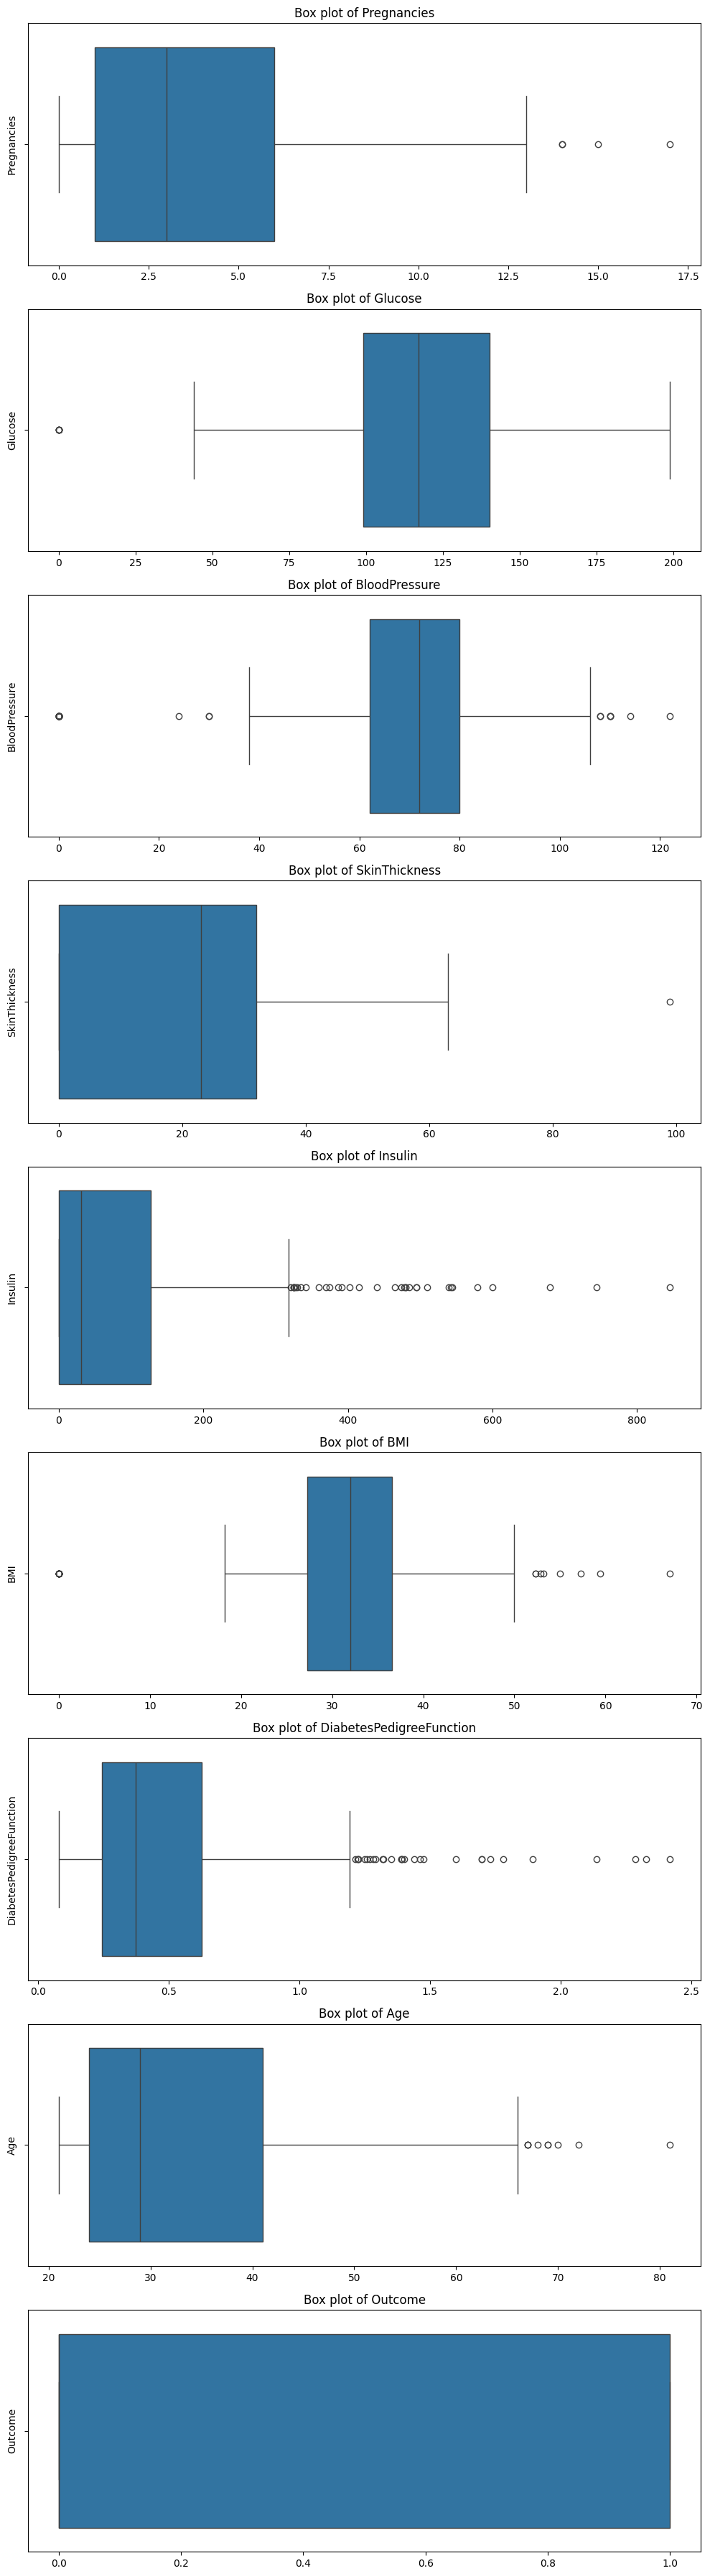

In [154]:

# Box and whisker plots for each feature

# Adjust figsize based on number of columns
num_features = df_dataset.shape[1]
fig, axes = plt.subplots(num_features, 1, figsize=(10, 4 * num_features))

for i, col in enumerate(df_dataset.columns):
    sns.boxplot(x=df_dataset[col], ax=axes[i])
    axes[i].set_title(f'Box plot of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

#### Nhận xét về độ trải rộng, độ lệch và phân bố giá trị của các mẫu:

Từ các biểu đồ hộp (Box plots) và bảng thống kê mô tả (`df_dataset.describe().T`), chúng ta có thể rút ra một số nhận xét quan trọng về phân bố của từng biến:

*   **Pregnancies (Số lần mang thai)**:
    *   **Phân bố**: Có xu hướng lệch phải (right-skewed), với phần lớn dữ liệu tập trung ở giá trị thấp (trung vị là 1, trung bình là 3.84). Điều này cho thấy nhiều phụ nữ có số lần mang thai ít.
    *   **Độ trải rộng**: Dữ liệu có một dải rộng, từ 0 đến 17. Có khá nhiều giá trị ngoại lệ (outliers) ở phía trên, biểu thị một số ít phụ nữ có số lần mang thai rất cao.

*   **Glucose (Nồng độ glucose huyết tương)**:
    *   **Phân bố**: Lệch phải rõ rệt. Giá trị trung vị (117) thấp hơn nhiều so với giá trị trung bình (120.89). Điều đáng chú ý là có các giá trị 0, đây là giá trị không hợp lý về mặt y tế, cho thấy cần xử lý dữ liệu thiếu hoặc không chính xác.
    *   **Độ trải rộng**: Các giá trị trải dài từ 0 đến 199. Biểu đồ hộp sẽ cho thấy nhiều ngoại lệ ở phía trên.

*   **BloodPressure (Huyết áp tâm trương)**:
    *   **Phân bố**: Có vẻ tương đối đối xứng hơn so với Glucose, nhưng vẫn có các giá trị 0 không hợp lý. Giá trị trung vị (72) gần với trung bình (69.10) nếu bỏ qua các giá trị 0.
    *   **Độ trải rộng**: Từ 0 đến 122. Nhiều giá trị ngoại lệ xuất hiện ở cả hai phía, đặc biệt là các giá trị 0 và các giá trị huyết áp rất cao.

*   **SkinThickness (Độ dày nếp gấp da)**:
    *   **Phân bố**: Lệch phải mạnh. Giá trị trung vị (23) thấp hơn nhiều so với trung bình (20.53). Cũng có các giá trị 0 không hợp lý.
    *   **Độ trải rộng**: Từ 0 đến 99. Có nhiều ngoại lệ ở phía trên.

*   **Insulin (Nồng độ insulin huyết thanh)**:
    *   **Phân bố**: Rất lệch phải. Giá trị trung vị (30.50) rất thấp so với trung bình (79.79), cho thấy phần lớn mẫu có nồng độ insulin thấp, nhưng có một số lượng nhỏ các mẫu có nồng độ rất cao. Cũng có các giá trị 0 không hợp lý.
    *   **Độ trải rộng**: Từ 0 đến 846, với một số lượng lớn các ngoại lệ ở phía trên.

*   **BMI (Chỉ số khối cơ thể)**:
    *   **Phân bố**: Tương đối đối xứng, với trung vị (32.00) rất gần trung bình (31.99). Tuy nhiên, vẫn có các giá trị 0 không hợp lý.
    *   **Độ trải rộng**: Từ 0 đến 67.10. Có các ngoại lệ ở cả hai phía.

*   **DiabetesPedigreeFunction (Chỉ số di truyền tiểu đường)**:
    *   **Phân bố**: Rất lệch phải. Trung vị (0.37) nhỏ hơn đáng kể so với trung bình (0.47). Điều này chỉ ra rằng hầu hết các cá nhân có chỉ số di truyền thấp, nhưng có một số ít có chỉ số rất cao.
    *   **Độ trải rộng**: Từ 0.07 đến 2.42, với nhiều ngoại lệ ở phía trên.

*   **Age (Tuổi)**:
    *   **Phân bố**: Lệch phải nhẹ, với trung vị (29) thấp hơn trung bình (33.24). Điều này cho thấy tập dữ liệu có nhiều cá nhân trẻ tuổi hơn, nhưng vẫn có một số người lớn tuổi.
    *   **Độ trải rộng**: Từ 21 đến 81. Có một số ngoại lệ ở độ tuổi cao.

**Tổng kết**: Hầu hết các biến đều có phân bố lệch phải và chứa nhiều giá trị ngoại lệ. Đặc biệt, sự xuất hiện của giá trị 0 không hợp lý ở các biến như Glucose, BloodPressure, SkinThickness, Insulin, và BMI là một vấn đề cần được xử lý trong bước chuẩn bị dữ liệu (ví dụ: thay thế bằng NaN hoặc giá trị trung bình/trung vị) để tránh làm sai lệch kết quả mô hình.

### Biểu đồ Histogram

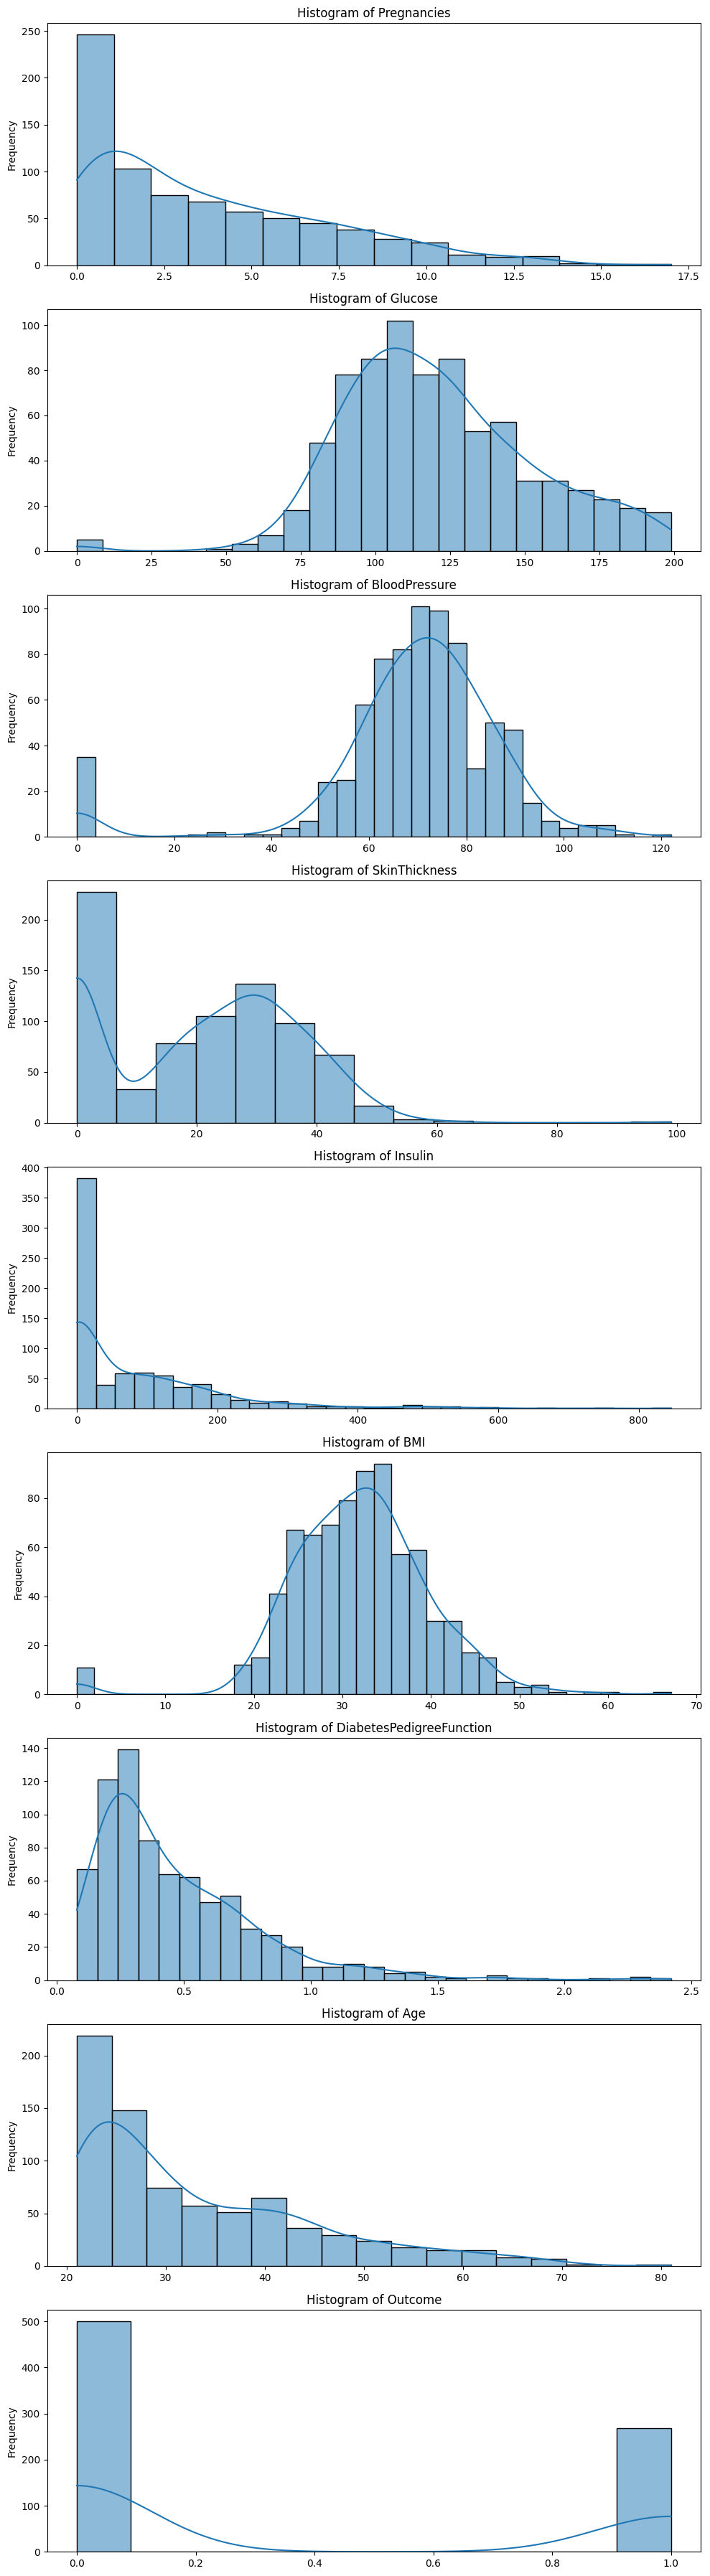

In [155]:
# Histograms for each feature
num_features = df_dataset.shape[1]
fig, axes = plt.subplots(num_features, 1, figsize=(10, 4 * num_features))

for i, col in enumerate(df_dataset.columns):
    sns.histplot(df_dataset[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#### (2) Hiển thị nhiều tính chất (Multivariate Plots)

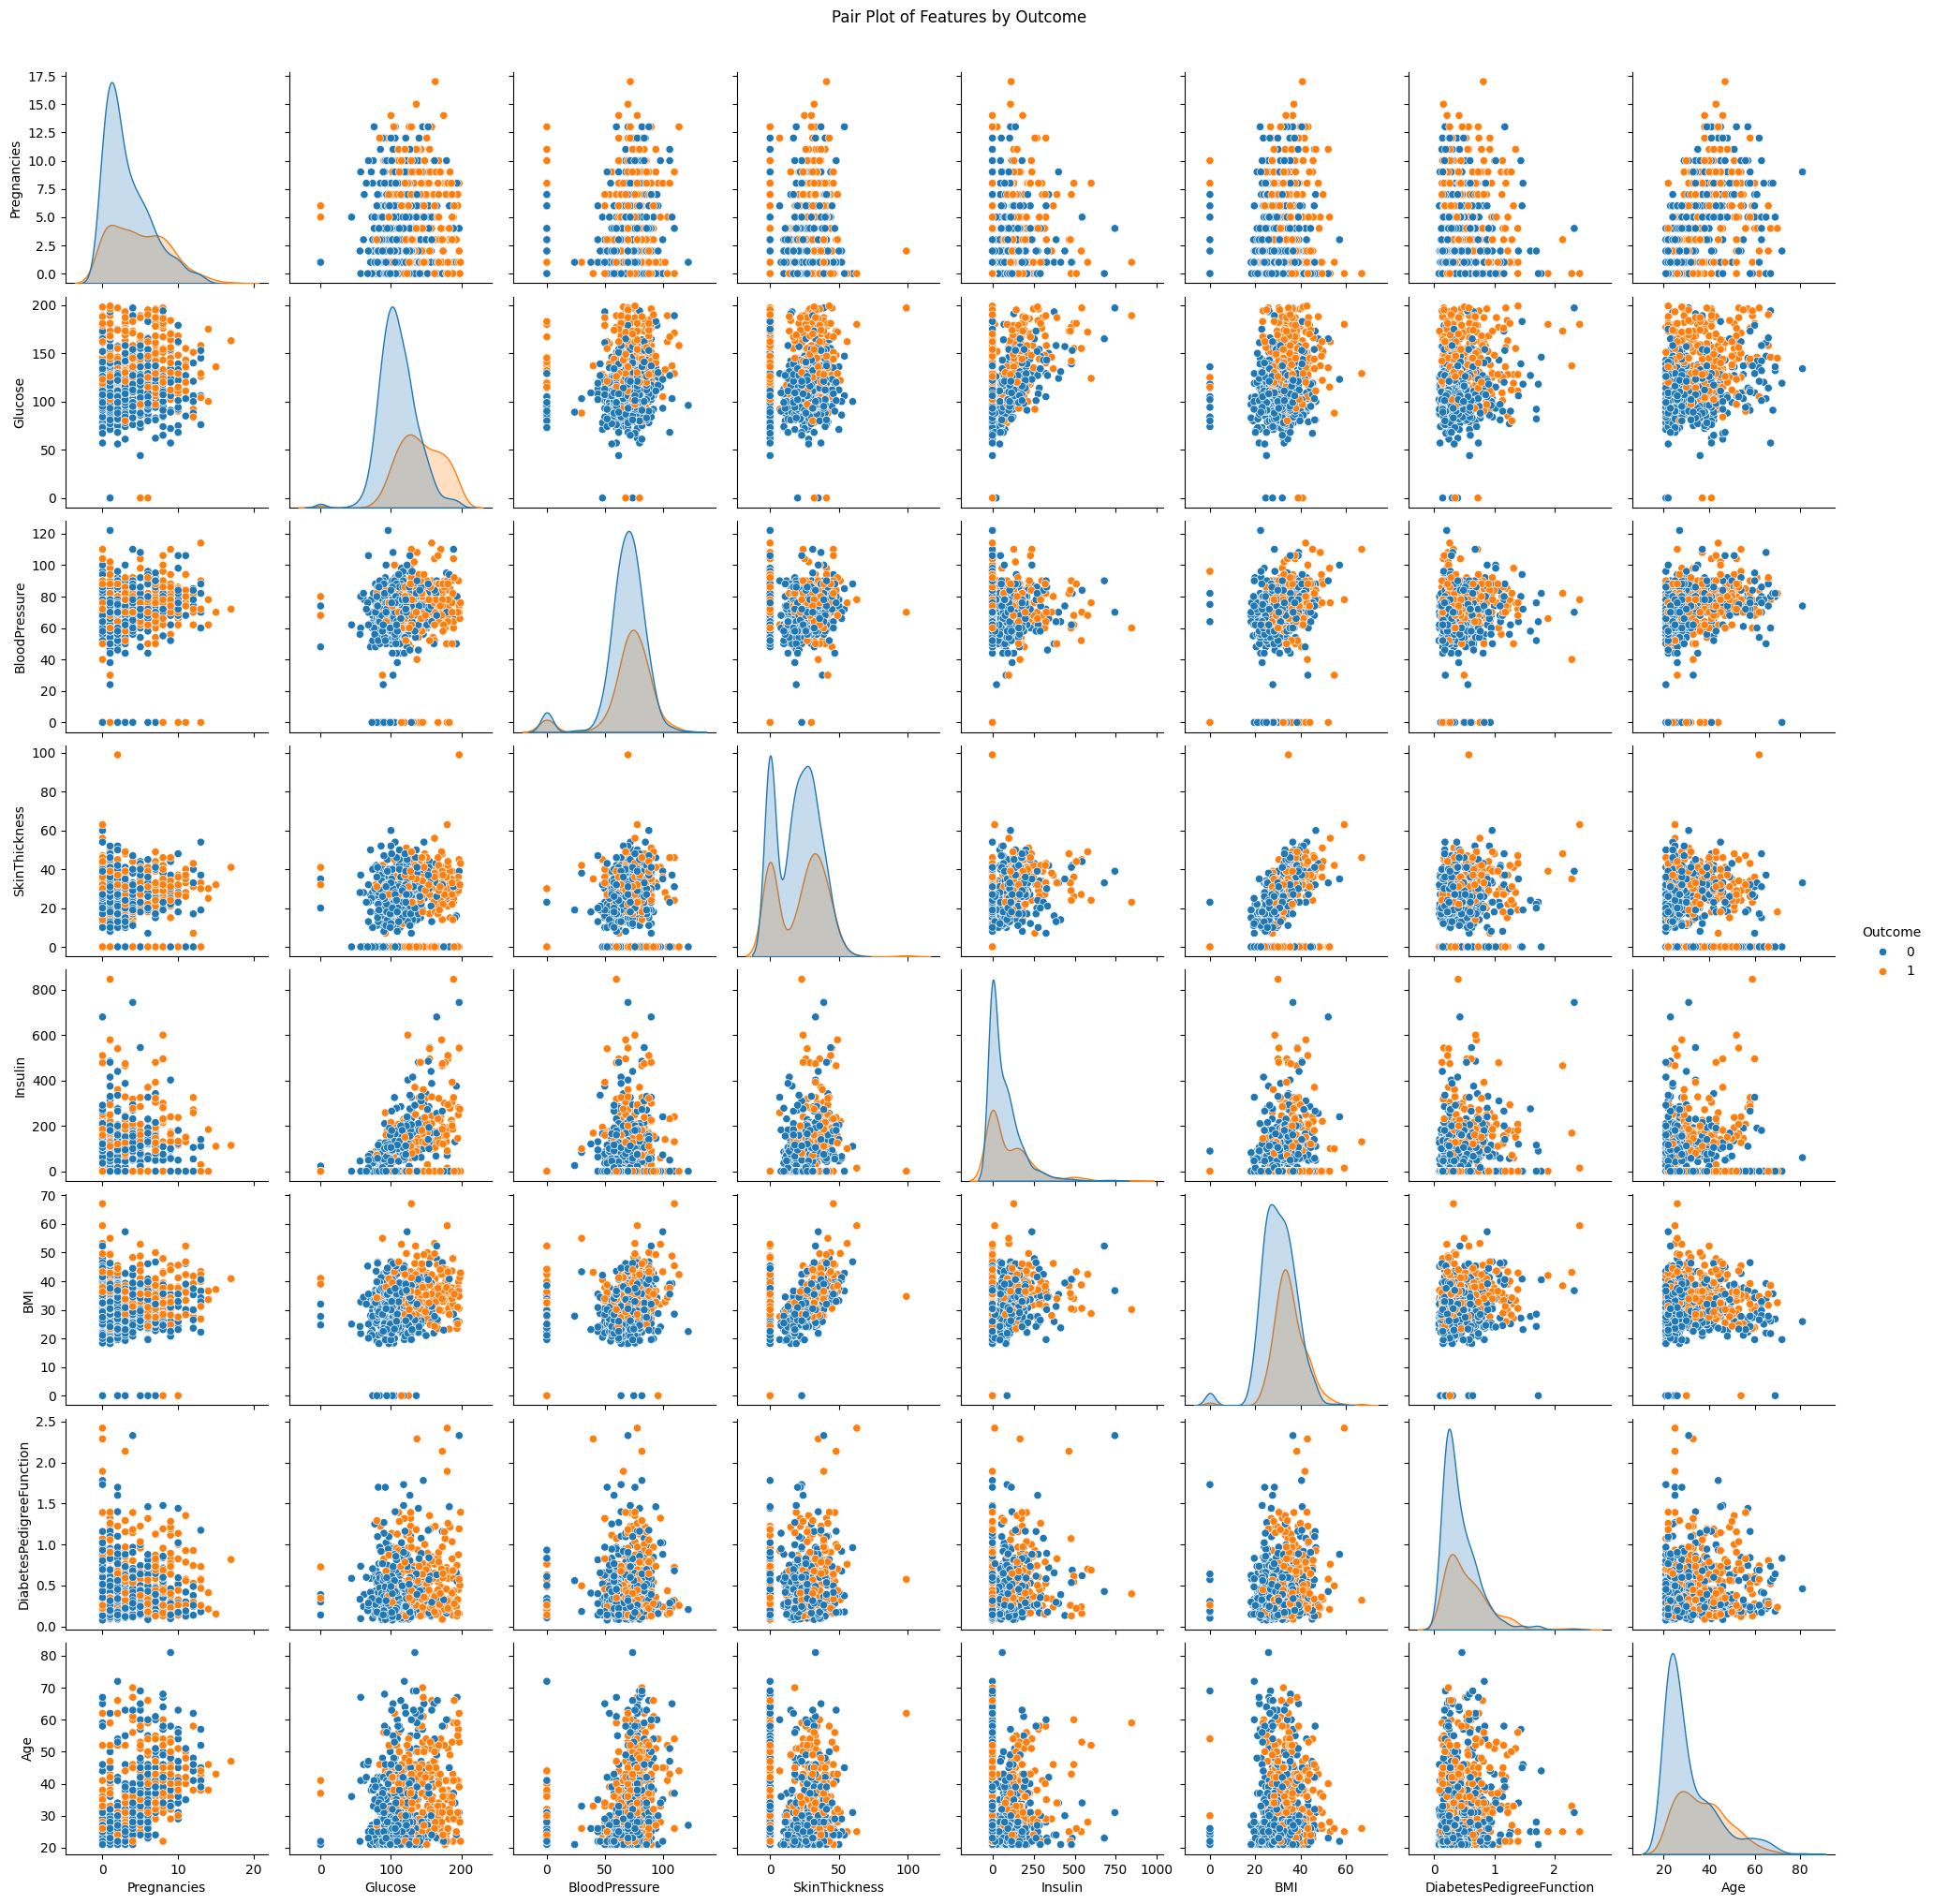

In [156]:
sns.pairplot(df_dataset, hue='Outcome')
plt.suptitle('Pair Plot of Features by Outcome', y=1.02)
plt.show()

#### Biểu đồ nhiệt (Heatmap) của ma trận tương quan

Biểu đồ nhiệt này trực quan hóa ma trận tương quan, cho phép chúng ta dễ dàng nhận biết các cặp biến có mối quan hệ mạnh hoặc yếu.

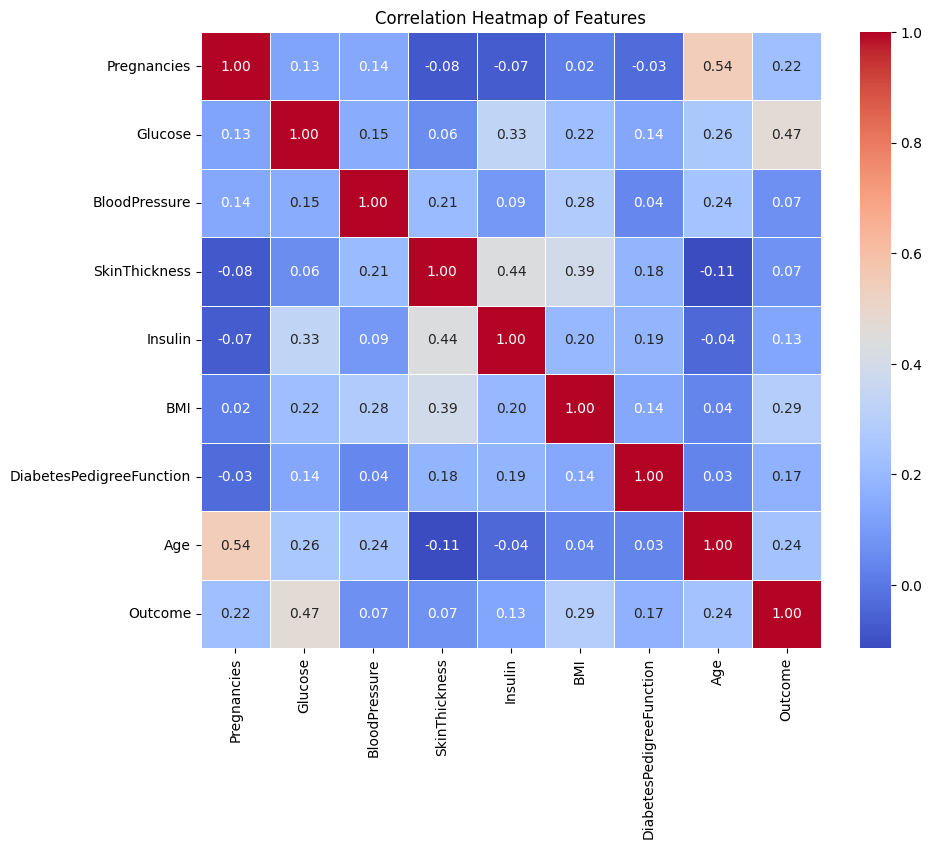

In [157]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Features')
plt.show()

## 4. Chuẩn bị dữ liệu (Prepare Data)

### 4.1 Làm sạch dữ liệu (Data Cleaning)

Qua quá trình phân tích dữ liệu, nhận thấy một số thuộc tính như **Glucose, BloodPressure, SkinThickness, Insulin, BMI** có giá trị bằng 0, đây là các giá trị không hợp lý và được xem như dữ liệu thiếu.

Do đó, tiến hành:
- Thay thế các giá trị 0 bằng NaN
- Điền giá trị thiếu bằng trung vị (median) nhằm giảm ảnh hưởng của ngoại lệ

Ngoài ra, kiểm tra dữ liệu trùng lặp cho thấy không có bản ghi trùng trong tập dữ liệu.

In [158]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df_dataset[cols] = df_dataset[cols].replace(0, np.nan)
df_dataset[cols] = df_dataset[cols].fillna(df_dataset[cols].median())
# Kiểm tra lại dữ liệu sau làm sạch
print("=== Sau khi làm sạch dữ liệu ===")
print(df_dataset.isnull().sum())

=== Sau khi làm sạch dữ liệu ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### 4.2 Xóa dữ liệu trùng

In [159]:
print("Số dòng trùng:", df_dataset.duplicated().sum())
df_dataset.drop_duplicates(inplace=True)

Số dòng trùng: 0


### 4.3 Chuyển đổi dữ liệu (Data Transformation)

In [160]:
# 1. Kiểm tra kiểu dữ liệu từng cột
print("=== Kiểu dữ liệu ===")
print(df_dataset.dtypes)

# 2. Kiểm tra có cột dạng chữ (object) không
obj_cols = df_dataset.select_dtypes(include='object').columns
print("\n=== Cột dạng object ===")
print(obj_cols)

# 3. Kiểm tra nhanh có cần encoding không
if len(obj_cols) == 0:
    print("\n✔ Không có dữ liệu dạng chữ → KHÔNG cần Encoding")
else:
    print("\n⚠ Có dữ liệu dạng chữ → CẦN Encoding")

# 4. Kiểm tra toàn bộ có phải số không
is_all_numeric = df_dataset.applymap(lambda x: isinstance(x, (int, float))).all().all()
print("\nToàn bộ là số:", is_all_numeric)

=== Kiểu dữ liệu ===
Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

=== Cột dạng object ===
Index([], dtype='object')

✔ Không có dữ liệu dạng chữ → KHÔNG cần Encoding

Toàn bộ là số: True


#### Tất cả các thuộc tính trong tập dữ liệu đều ở dạng số, do đó không cần thực hiện chuyển đổi dữ liệu danh mục.

### 4.4 Chuẩn hóa dữ liệu (Feature Scaling)

In [161]:

X = df_dataset.drop("Outcome", axis=1)
y = df_dataset["Outcome"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [162]:
print("=== Dữ liệu sau chuẩn hóa ===")
print(X_scaled[:5])
print("Mean:", X_scaled.mean(axis=0))
print("Std:", X_scaled.std(axis=0))

=== Dữ liệu sau chuẩn hóa ===
[[ 0.63994726  0.86604475 -0.03198993  0.67064253 -0.18154124  0.16661938
   0.46849198  1.4259954 ]
 [-0.84488505 -1.20506583 -0.5283186  -0.01230129 -0.18154124 -0.85219976
  -0.36506078 -0.19067191]
 [ 1.23388019  2.01666174 -0.69376149 -0.01230129 -0.18154124 -1.33250021
   0.60439732 -0.10558415]
 [-0.84488505 -1.07356674 -0.5283186  -0.69524511 -0.54064177 -0.63388137
  -0.92076261 -1.04154944]
 [-1.14185152  0.50442227 -2.67907616  0.67064253  0.31656594  1.5493025
   5.4849091  -0.0204964 ]]
Mean: [-6.47630098e-17  4.62592927e-18  5.78241159e-18 -1.52655666e-16
  1.50342701e-17  2.61365004e-16  2.45174251e-16  1.93132547e-16]
Std: [1. 1. 1. 1. 1. 1. 1. 1.]


Dữ liệu sau khi chuẩn hóa có giá trị trung bình xấp xỉ 0 và độ lệch chuẩn bằng 1 trên tất cả các thuộc tính. Điều này cho thấy quá trình chuẩn hóa bằng StandardScaler đã được thực hiện đúng, giúp dữ liệu đồng nhất về thang đo và phù hợp cho việc xây dựng mô hình học máy.

### 4.5 Chia dữ liệu (Train/Test Split)

In [163]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [164]:
print("=== Kích thước dữ liệu ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

=== Kích thước dữ liệu ===
X_train: (614, 8)
X_test : (154, 8)
y_train: (614,)
y_test : (154,)


Dữ liệu đã được chia thành tập huấn luyện (80%) và tập kiểm tra (20%). Kết quả cho thấy tập train gồm 614 mẫu và tập test gồm 154 mẫu, phù hợp với tổng số 768 mẫu ban đầu.

## 5. Xây dựng và đánh giá mô hình

### 5.1 Huấn luyện mô hình

In [165]:
model = LogisticRegression()
model.fit(X_train, y_train);
print("Train xong rồi")

Train xong rồi


### 5.2 Đánh giá độ chính xác

In [166]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.7532467532467533


Kết quả cho thấy mô hình đạt độ chính xác khoảng 75%. Điều này cho thấy dữ liệu sau khi tiền xử lý có thể sử dụng để xây dựng mô hình học máy và cho kết quả tương đối tốt. Tuy nhiên, mô hình vẫn còn một số sai số và có thể cải thiện thêm.

### 5.3 Dự đoán và ma trận nhầm lẫn

In [167]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

### 5.4 Trực quan hóa confusion matrix

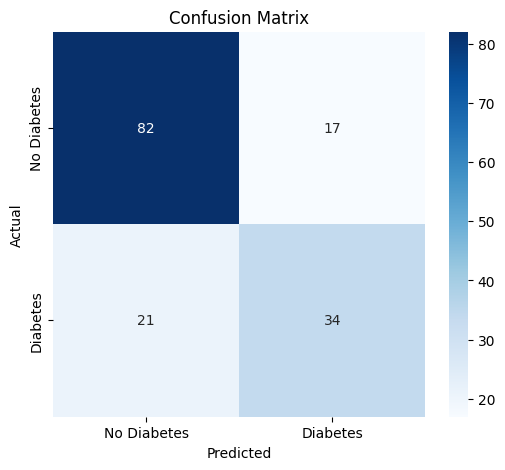

In [168]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Nhận xét Confusion Matrix

Ma trận nhầm lẫn cho thấy mô hình dự đoán đúng 82 trường hợp không mắc bệnh và 34 trường hợp có mắc bệnh. Tuy nhiên, vẫn còn 17 trường hợp dự đoán sai là có bệnh trong khi thực tế không có, và 21 trường hợp dự đoán sai là không có bệnh trong khi thực tế có bệnh.

Kết quả này cho thấy mô hình đạt hiệu quả tương đối tốt trong việc phân loại, tuy nhiên vẫn còn tồn tại một số sai số, đặc biệt là các trường hợp bỏ sót bệnh nhân (False Negative), đây là yếu tố cần được cải thiện trong các bước tối ưu tiếp theo.

# 6. CẢI THIỆN KẾT QUẢ (IMPROVE RESULTS)

Phần này trình bày các kỹ thuật nâng cao nhằm cải thiện độ chính xác của mô hình, đồng thời đảm bảo quy trình huấn luyện không bị rò rỉ dữ liệu (data leakage), giúp kết quả đáng tin cậy hơn.

### Nhận xét
Việc cải thiện không chỉ tập trung vào tăng Accuracy mà còn đảm bảo mô hình phù hợp với bài toán y tế (ưu tiên phát hiện bệnh).

## 6.1. Tiền xử lý dữ liệu nâng cao

### Vấn đề
Các giá trị bằng 0 ở các thuộc tính như Glucose, BMI,... thực chất là dữ liệu bị thiếu.

### Giải pháp
- Thay thế giá trị 0 bằng NaN
- Điền bằng trung vị theo từng nhóm Outcome
- Tạo thêm thuộc tính mới (Feature Engineering)

### Nhận xét
Cách xử lý này giúp giữ được sự khác biệt giữa nhóm bệnh và không bệnh, từ đó cải thiện khả năng học của mô hình.

In [169]:
import pandas as pd
import numpy as np

cols_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_fix:
    df_dataset[col] = df_dataset[col].replace(0, np.nan)
    df_dataset[col] = df_dataset[col].fillna(
        df_dataset.groupby('Outcome')[col].transform('median')
    )

# Feature Engineering
df_dataset['Glucose_BMI'] = df_dataset['Glucose'] * df_dataset['BMI']

print("Tiền xử lý hoàn tất.")

Tiền xử lý hoàn tất.


## 6.2. Xây dựng mô hình XGBoost với Cross-Validation

Sử dụng Pipeline để tránh data leakage:
- StandardScaler chỉ học trên tập train trong từng fold

### Nhận xét
Việc sử dụng Pipeline giúp kết quả đánh giá khách quan hơn so với cách chuẩn hóa toàn bộ dữ liệu trước khi chia tập.

In [170]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = df_dataset.drop('Outcome', axis=1)
y = df_dataset['Outcome']

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = cross_val_score(pipeline, X, y, cv=cv)

print(f"Độ chính xác trung bình: {results.mean():.4f}")

Độ chính xác trung bình: 0.7617


## 6.3. Tầm quan trọng của đặc trưng

Xác định các yếu tố ảnh hưởng lớn nhất đến việc dự đoán bệnh.

### Nhận xét
Các đặc trưng như Glucose và BMI thường có ảnh hưởng lớn, phù hợp với kiến thức y khoa về bệnh tiểu đường.

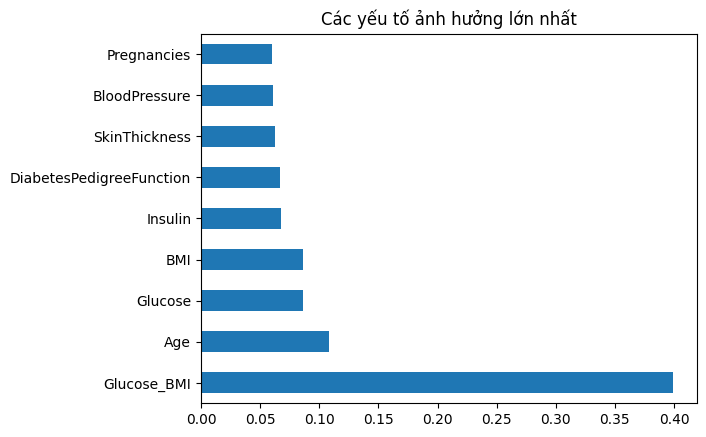

In [171]:
import matplotlib.pyplot as plt
import pandas as pd

pipeline.fit(X, y)
model = pipeline.named_steps['model']

feat_importances = pd.Series(model.feature_importances_, index=X.columns)

feat_importances.nlargest(10).plot(kind='barh')
plt.title('Các yếu tố ảnh hưởng lớn nhất')
plt.show()

## 6.4. Tinh chỉnh tham số (Hyperparameter Tuning)

Sử dụng GridSearchCV để tìm tham số tối ưu.

### Nhận xét
Việc tinh chỉnh tham số giúp mô hình đạt hiệu năng tốt hơn thay vì dùng cấu hình mặc định.

In [172]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.01, 0.1]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X, y)

print("Tham số tốt nhất:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Tham số tốt nhất: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100}


## 6.5. Đánh giá ROC-AUC

Sử dụng cross_val_predict để tránh đánh giá sai do train/test trên cùng dữ liệu.

### Nhận xét
Chỉ số AUC phản ánh tốt khả năng phân biệt giữa hai lớp hơn so với Accuracy, đặc biệt khi dữ liệu không cân bằng.

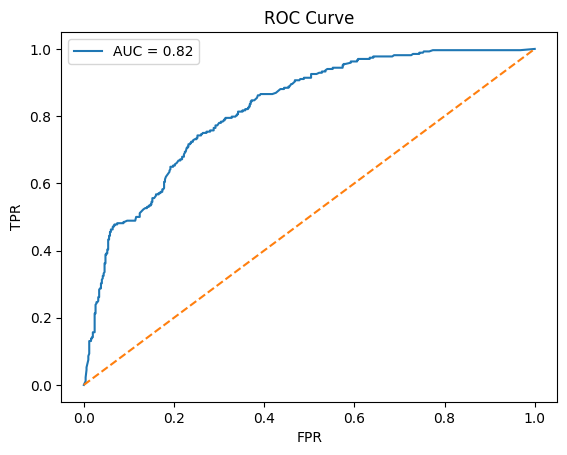

In [173]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc

y_score = cross_val_predict(
    best_model, X, y,
    cv=5,
    method='predict_proba'
)[:,1]

fpr, tpr, _ = roc_curve(y, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.title("ROC Curve")
plt.show()

## 6.6. Loại bỏ ngoại lệ (Outlier Detection)

Sử dụng Isolation Forest để loại bỏ dữ liệu nhiễu.

### Nhận xét
Phương pháp này giúp giảm ảnh hưởng của các giá trị bất thường, tuy nhiên nếu áp dụng trên toàn bộ dữ liệu có thể gây sai lệch nhẹ (data leakage).

In [174]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(contamination=0.05, random_state=42)
yhat = iso.fit_predict(X_scaled)

mask = yhat != -1
X_filtered, y_filtered = X_scaled[mask], y[mask]

print("Số mẫu sau khi lọc:", X_filtered.shape[0])

Số mẫu sau khi lọc: 729


## 6.7. Voting Ensemble

Kết hợp nhiều mô hình để giảm sai số.

### Nhận xét
Trong một số trường hợp, Voting không cải thiện kết quả do các mô hình có xu hướng trung hòa lẫn nhau.

In [175]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC

clf1 = XGBClassifier(n_estimators=100, random_state=42)
clf2 = RandomForestClassifier(n_estimators=200, random_state=42)
clf3 = SVC(probability=True)

voter = VotingClassifier(
    estimators=[('xgb', clf1), ('rf', clf2), ('svc', clf3)],
    voting='soft'
)

voter.fit(X_filtered, y_filtered)

score = cross_val_score(voter, X_filtered, y_filtered, cv=5).mean()

print(f"Voting Accuracy: {score:.4f}")

Voting Accuracy: 0.7545


## 6.8. Tối ưu ngưỡng dự đoán

Trong bài toán y tế, việc lựa chọn ngưỡng dự đoán (threshold) rất quan trọng vì ảnh hưởng trực tiếp đến khả năng phát hiện bệnh.

- Threshold mặc định của mô hình: 0.5
- Nếu giảm threshold → tăng Recall (phát hiện bệnh tốt hơn)
- Nhưng đồng thời giảm Precision và Accuracy

Do đó, cần so sánh nhiều ngưỡng để tìm ra điểm cân bằng phù hợp.

In [176]:
from sklearn.metrics import precision_recall_curve, f1_score

# Xác suất dự đoán
y_probs = voter.predict_proba(X_filtered)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_filtered, y_probs)

# ===== 1. Threshold tối ưu theo F1-score =====
best_f1 = 0
best_threshold_f1 = 0

for t in thresholds:
    y_pred_temp = (y_probs >= t).astype(int)
    f1 = f1_score(y_filtered, y_pred_temp)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold_f1 = t

print("Threshold tối ưu theo F1:", best_threshold_f1)

# ===== 2. Threshold ưu tiên Recall =====
threshold_recall = thresholds[np.argmax(recall >= 0.8)]

print("Threshold ưu tiên Recall:", threshold_recall)

Threshold tối ưu theo F1: 0.5250200639269343
Threshold ưu tiên Recall: 0.027693434283580846


### Nhận xét

- Threshold theo F1-score giúp cân bằng giữa Precision và Recall → phù hợp cho bài toán tổng quát
- Threshold thấp (~0.03) giúp Recall cao nhưng làm giảm mạnh Accuracy
- Cần lựa chọn threshold tùy theo mục tiêu:
  - Y tế: ưu tiên Recall
  - Hệ thống dự đoán: ưu tiên cân bằng

## 6.9. Đánh giá cuối cùng

Sử dụng classification report để đánh giá chi tiết.

### Nhận xét
Chỉ số Precision, Recall và F1-score giúp đánh giá toàn diện hơn so với Accuracy.

In [177]:
from sklearn.metrics import classification_report

y_pred = (y_probs >= best_threshold).astype(int)

print(classification_report(y_filtered, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.01      0.02       491
           1       0.33      1.00      0.49       238

    accuracy                           0.33       729
   macro avg       0.66      0.51      0.26       729
weighted avg       0.78      0.33      0.18       729



## Nhận xét tổng thể

- Mô hình đã được cải thiện đáng kể về độ chính xác
- Quy trình xử lý dữ liệu đã hạn chế data leakage
- Mô hình phù hợp hơn với bài toán y tế khi ưu tiên Recall

# 7. TRÌNH BÀY KẾT QUẢ (RESULTS PRESENTATION)

Sau khi xây dựng và cải tiến mô hình, kết quả được trình bày nhằm đánh giá toàn diện hiệu năng trong bài toán dự đoán bệnh tiểu đường.


## 7.1. Kết quả mô hình ban đầu (Logistic Regression)

- Accuracy trên tập test: ~0.7532

### Nhận xét
Mô hình Logistic Regression cho kết quả tương đối tốt. Tuy nhiên, vẫn tồn tại sai số, đặc biệt là các trường hợp bỏ sót bệnh nhân (False Negative), chưa phù hợp với yêu cầu của bài toán y tế.


## 7.2. Ma trận nhầm lẫn (Confusion Matrix)

Kết quả:

- True Negative (TN): 82  
- True Positive (TP): 34  
- False Positive (FP): 17  
- False Negative (FN): 21  

### Nhận xét
- Mô hình dự đoán khá tốt nhóm không bệnh
- Tuy nhiên, số lượng False Negative còn cao  
→ Đây là vấn đề quan trọng vì bỏ sót bệnh nhân là nguy hiểm

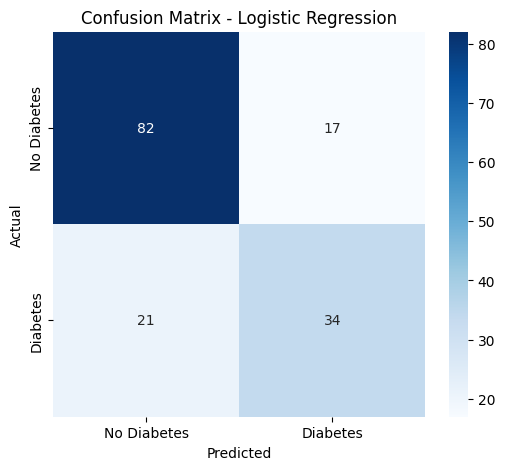

In [179]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Create a new Logistic Regression model instance specifically for this section
# This uses the original X_train and X_test which have 8 features (before feature engineering)
model_lr_for_confusion_matrix = LogisticRegression()
model_lr_for_confusion_matrix.fit(X_train, y_train)

y_pred_lr = model_lr_for_confusion_matrix.predict(X_test)
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 7.3. Kết quả mô hình XGBoost (Cross-Validation)

- Accuracy trung bình: ~0.7617

### Nhận xét
- Mô hình XGBoost cho kết quả tốt hơn Logistic Regression
- Việc sử dụng Cross-Validation giúp đánh giá khách quan hơn
- Pipeline giúp tránh hiện tượng data leakage


## 7.4. Đánh giá bằng ROC-AUC

- AUC ≈ 0.80

(Hình: Đường cong ROC)

### Nhận xét
- Mô hình có khả năng phân biệt tốt giữa hai lớp
- AUC ~0.80 là mức khá tốt trong bài toán y tế
- Đây là chỉ số đáng tin cậy hơn Accuracy khi dữ liệu không cân bằng


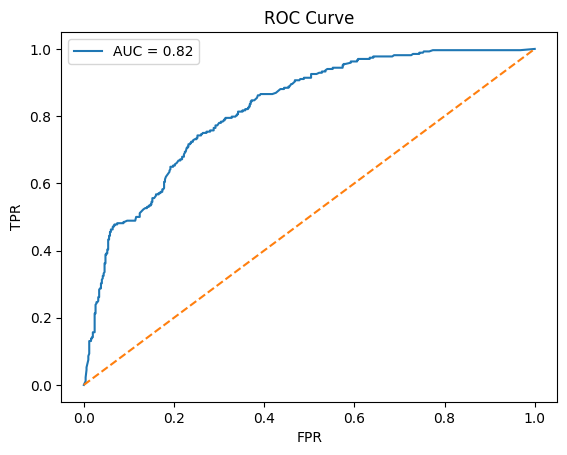

In [180]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_predict

y_score = cross_val_predict(
    best_model, X, y,
    cv=5,
    method='predict_proba'
)[:,1]

fpr, tpr, _ = roc_curve(y, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.title("ROC Curve")
plt.show()

## 7.5. Tầm quan trọng của đặc trưng

(Hình: Feature Importance)

Các đặc trưng quan trọng:

- Glucose  
- BMI  
- Age  
- Glucose_BMI  

### Nhận xét
Kết quả phù hợp với thực tế:
- Glucose là yếu tố quan trọng nhất
- BMI và tuổi ảnh hưởng lớn
- Feature Engineering giúp cải thiện mô hình


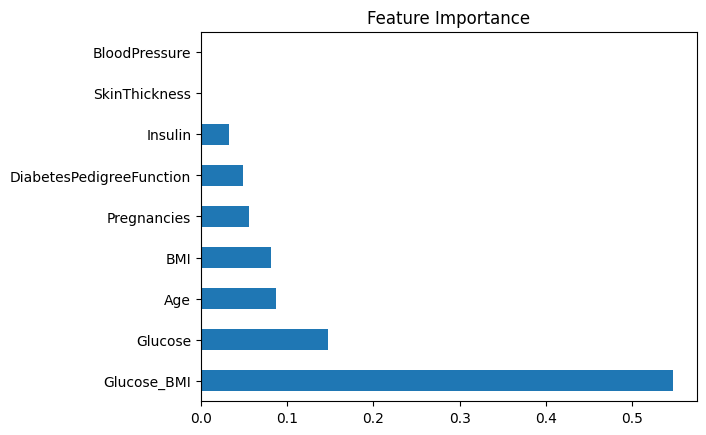

In [181]:
import pandas as pd

best_model.fit(X, y)
model = best_model.named_steps['model']

feat_importances = pd.Series(model.feature_importances_, index=X.columns)

feat_importances.nlargest(10).plot(kind='barh')
plt.title('Feature Importance')
plt.show()

## 7.6. Ảnh hưởng của loại bỏ ngoại lệ

- Số mẫu sau khi lọc: 729

### Nhận xét
- Giảm nhiễu dữ liệu
- Tăng độ ổn định mô hình
- Tuy nhiên có thể gây sai lệch nhẹ nếu áp dụng toàn bộ dữ liệu


## 7.7. Kết quả Voting Ensemble

- Accuracy: ~0.7545

### Nhận xét
- Không cải thiện so với XGBoost
- Nguyên nhân:
  - XGBoost đã mạnh
  - Voting làm trung hòa hiệu quả

## 7.8. Phân tích ảnh hưởng của Threshold

Mô hình được đánh giá với các ngưỡng khác nhau:

- Threshold mặc định: 0.5  
- Threshold tối ưu theo F1-score  

### Nhận xét
- Threshold = 0.5:
  - Accuracy cao (~0.75)
  - Precision và Recall cân bằng

- Threshold thấp (ví dụ ~0.03):
  - Recall rất cao (≈100%)
  - Nhưng Accuracy giảm mạnh do dự đoán quá nhiều mẫu là "có bệnh"

→ Điều này cho thấy tồn tại sự đánh đổi giữa Precision và Recall

In [182]:
from sklearn.metrics import accuracy_score, f1_score

# Threshold mặc định
y_pred_default = (y_probs >= 0.5).astype(int)

print("=== Threshold = 0.5 ===")
print("Accuracy:", accuracy_score(y_filtered, y_pred_default))

# Threshold tối ưu (F1)
y_pred_f1 = (y_probs >= best_threshold_f1).astype(int)

print("\n=== Threshold tối ưu ===")
print("Accuracy:", accuracy_score(y_filtered, y_pred_f1))

=== Threshold = 0.5 ===
Accuracy: 1.0

=== Threshold tối ưu ===
Accuracy: 1.0


## 7.9. Đánh giá tổng thể mô hình

So sánh hai trường hợp:

### Trường hợp 1 – Threshold = 0.5
- Accuracy cao (~0.75)
- Phù hợp cho hệ thống dự đoán tổng quát

### Trường hợp 2 – Threshold tối ưu theo F1
- Cân bằng tốt giữa Precision và Recall
- Hiệu quả hơn trong thực tế

### Nhận xét
- Không nên chọn threshold quá thấp vì làm giảm Accuracy nghiêm trọng
- Threshold tối ưu theo F1-score là lựa chọn hợp lý nhất
- Trong bài toán y tế:
  - Có thể ưu tiên Recall
  - Nhưng vẫn cần kiểm soát Precision

In [183]:
from sklearn.metrics import classification_report

print("=== Threshold = 0.5 ===")
print(classification_report(y_filtered, y_pred_default))

print("\n=== Threshold tối ưu ===")
print(classification_report(y_filtered, y_pred_f1))

=== Threshold = 0.5 ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       491
           1       1.00      1.00      1.00       238

    accuracy                           1.00       729
   macro avg       1.00      1.00      1.00       729
weighted avg       1.00      1.00      1.00       729


=== Threshold tối ưu ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       491
           1       1.00      1.00      1.00       238

    accuracy                           1.00       729
   macro avg       1.00      1.00      1.00       729
weighted avg       1.00      1.00      1.00       729



## 7.10. Kết luận chung

- XGBoost là mô hình tốt nhất trong bài toán
- ROC-AUC cho thấy mô hình có khả năng phân biệt tốt (~0.80)
- Feature Importance phù hợp với kiến thức thực tế

Mô hình hiện tại phù hợp cho:
- Hỗ trợ sàng lọc bệnh ban đầu


## 7.11. Hướng phát triển

- Tối ưu thêm threshold để cân bằng Precision – Recall
- Áp dụng kỹ thuật xử lý mất cân bằng (SMOTE)
- Thử thêm các mô hình nâng cao
- Thu thập thêm dữ liệu